## 2_macroeconomic_influence_on_hpi.ipynb

This code analyzes the relationship between the Ames House Price Index (HPI) and key macroeconomic factors by preprocessing, merging, and visualizing quarterly data to explore their correlations.

### 1. Imports Library

In [1]:
# Imports Library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import warnings
warnings.filterwarnings("ignore", category=Warning)

### 2. Load and Preprocess Ames House Price Index data

In [2]:
#  Load Ames House Price Index data
df_hpi = pd.read_csv(Path("data/Ames House Price Index.csv"))
df_hpi.head(2)

,observation_date,ATNHPIUS11180Q
0,1990-01-01,76.43
1,1990-04-01,76.58


In [3]:
# Preprocess df_hpi
# Rename to consistent column names
df_hpi = df_hpi.rename(columns={
    "observation_date": "Date",
    "ATNHPIUS11180Q": "HPI"
})

# Parse dates
df_hpi["Date"] = pd.to_datetime(df_hpi["Date"])

# Create YearQuarter column 
df_hpi["YearQuarter"] = df_hpi["Date"].dt.to_period("Q")

# Ensure numeric 
df_hpi["HPI"] = pd.to_numeric(df_hpi["HPI"], errors="coerce")

# Set index
df_hpi_q = df_hpi.set_index("YearQuarter").sort_index()

# Drop the original Date column if you only want to merge on Quarter
df_hpi_q = df_hpi_q.drop(columns=["Date"])

df_hpi_q.head()

,HPI
YearQuarter,
1990Q1,76.43
1990Q2,76.58
1990Q3,78.72
1990Q4,78.86
1991Q1,81.22


### 3. Load and Preprocess CrimeRate, InterestRate, and UnemploymentRate dataset

#### 1) Load and preprocess CrimeRate dataset

In [4]:
# Load CrimeRate data
df_crime = pd.read_csv(Path("data/Crime_Rate_lowa.csv"))
df_crime.head(2)

,Year,Population,Index,Violent,Property,Murder
0,1990,2776755,113871,8321,105550,54
1,1991,2795000,115546,8477,107069,57


In [5]:
# Calculate CrimeRate
df_crime["Index"] = df_crime["Index"].replace(',', '', regex=True).astype(int)
df_crime["Population"] = df_crime["Population"].replace(',', '', regex=True).astype(int)
df_crime["CrimeRate"] = df_crime["Index"] / df_crime["Population"] * 1000
df_crime.head()

,Year,Population,Index,Violent,Property,Murder,CrimeRate
0,1990,2776755,113871,8321,105550,54,41.008659
1,1991,2795000,115546,8477,107069,57,41.340250
2,1992,2812000,111275,7816,103459,44,39.571479
3,1993,2814000,108239,9159,99080,66,38.464463
4,1994,2829000,103389,8914,94475,47,36.546129


In [6]:
# Preprocess df_crime

# Create mapping dictionary
yr_to_rate = df_crime.dropna(subset=["Year", "CrimeRate"]).set_index("Year")["CrimeRate"]

# Build full quarterly PERIOD index
start_year = int(df_crime["Year"].min())
end_year = int(df_crime["Year"].max())

# Create range of Quarters
q_index = pd.period_range(start=f"{start_year}Q1", end=f"{end_year}Q4", freq="Q")

# Map annual rates to quarters
df_crime_q = pd.DataFrame({"YearQuarter": q_index})
df_crime_q["Year"] = df_crime_q["YearQuarter"].dt.year
df_crime_q["CrimeRate"] = df_crime_q["Year"].map(yr_to_rate)

# Clean up
df_crime_q = df_crime_q.drop(columns=["Year"])
df_crime_q["CrimeRate"] = df_crime_q["CrimeRate"].round(6)

df_crime_q.head()

,YearQuarter,CrimeRate
0,1990Q1,41.008659
1,1990Q2,41.008659
2,1990Q3,41.008659
3,1990Q4,41.008659
4,1991Q1,41.340250


#### 2) Load and preprocess InterestRate

In [7]:
# Load InterestRate data
df_mortgage = pd.read_csv(Path("data/Mortgage Rates USA.csv"))
df_mortgage.head(2)

,observation_date,MORTGAGE30US
0,1/5/1990,9.83
1,1/12/1990,9.80


In [8]:
# Prepcrocess mortgage df

# Rename to consistent column names
df_mortgage = df_mortgage.rename(columns={"observation_date": "Date", "MORTGAGE30US": "MortgageRate"})
df_mortgage["Date"] = pd.to_datetime(df_mortgage["Date"], errors="coerce", infer_datetime_format=True)
df_mortgage["MortgageRate"] = pd.to_numeric(df_mortgage["MortgageRate"], errors="coerce")

# Create YearQuarter column
df_mortgage["YearQuarter"] = df_mortgage["Date"].dt.to_period("Q")

# Group by YearQuarter and take the mean
df_mortgage_q = df_mortgage.groupby("YearQuarter", as_index=False)["MortgageRate"].mean()
df_mortgage_q["MortgageRate"] = df_mortgage_q["MortgageRate"].round(4)

df_mortgage_q.head()

,YearQuarter,MortgageRate
0,1990Q1,10.1315
1,1990Q2,10.3238
2,1990Q3,10.1031
3,1990Q4,9.9592
4,1991Q1,9.5008


#### 3) Load and preprocess UnemploymentRate

In [9]:
# Load UnemploymentRate data
df_unemployment = pd.read_csv(Path("data/AMES Unemployment Rate.csv"))
df_unemployment.head()

,observation_date,AMES119URN
0,1990-01-01,4.2
1,1990-02-01,3.8
2,1990-03-01,3.4
3,1990-04-01,3.2
4,1990-05-01,3.5


In [10]:
# Preprocess unemployment df

# Rename to consistent column names
df_unemployment = df_unemployment.rename(columns={"observation_date": "Date", "AMES119URN": "Unemployment"})
df_unemployment["Date"] = pd.to_datetime(df_unemployment["Date"], errors="coerce")
df_unemployment["Unemployment"] = pd.to_numeric(df_unemployment["Unemployment"], errors="coerce")

# Create YearQuarter column
df_unemployment["YearQuarter"] = df_unemployment["Date"].dt.to_period("Q")

# Group by YearQuarter and take the mean
df_unemployment_q = df_unemployment.groupby("YearQuarter", as_index=False)["Unemployment"].mean()
df_unemployment_q["Unemployment"] = df_unemployment_q["Unemployment"].round(3)

# Check
df_unemployment_q.head()

,YearQuarter,Unemployment
0,1990Q1,3.800
1,1990Q2,3.500
2,1990Q3,4.000
3,1990Q4,4.200
4,1991Q1,4.467


#### 4) Load and preprocess MedianIncome

In [11]:
# Load MedianIncome data
df_income = pd.read_csv(Path("data/Ames Median Household Income.csv"))
df_income.head()

,Year,MedianIncome
0,1984,"19,860"
1,1985,"20,930"
2,1986,"22,460"
3,1987,"22,190"
4,1988,"24,310"


In [12]:
# Preprocess MedianIncome df

# Clean & standardize 
df_income = df_income.loc[:, ["Year", "MedianIncome"]].dropna()
df_income["Year"] = df_income["Year"].astype(int)
df_income["MedianIncome"] = (
    df_income["MedianIncome"].astype(str).str.replace(",", "", regex=True).astype(float)
)

# Map: year to income
yr_to_income = df_income.set_index("Year")["MedianIncome"]

# Use the HPI period index to ensure alignment, or create new range
if "df_hpi_q" in globals():
    # Use the index from HPI (which is now YearQuarter periods)
    q_index = df_hpi_q.index 
else:
    start_year = int(df_income["Year"].min())
    end_year = int(df_income["Year"].max())
    q_index = pd.period_range(f"{start_year}Q1", f"{end_year}Q4", freq="Q")

df_income_q = pd.DataFrame({"YearQuarter": q_index})
df_income_q["Year"] = df_income_q["YearQuarter"].dt.year
df_income_q["MedianIncome"] = df_income_q["Year"].map(yr_to_income)

df_income_q = df_income_q.drop(columns=["Year"]).sort_values("YearQuarter").reset_index(drop=True)
df_income_q["MedianIncome"] = df_income_q["MedianIncome"].round(2)

# Check
df_income_q.head()


,YearQuarter,MedianIncome
0,1990Q1,27290.0
1,1990Q2,27290.0
2,1990Q3,27290.0
3,1990Q4,27290.0
4,1991Q1,28550.0


### 4. Merge all micro datasets with Ames HPI based on 'Date'

In [13]:
# Merge all datasets on Date
# Start with HPI as base. Reset index to make 'YearQuarter' a column for merging if it's currently the index
df_q = df_hpi_q.reset_index() 

# Merge CrimeRate
df_q = df_q.merge(df_crime_q, on="YearQuarter", how="left")

# Merge MortgageRate
df_q = df_q.merge(df_mortgage_q, on="YearQuarter", how="left")

# Merge Unemployment
df_q = df_q.merge(df_unemployment_q, on="YearQuarter", how="left")

# Merge MedianIncome
df_q = df_q.merge(df_income_q, on="YearQuarter", how="left")

# Clean
df_q_clean = df_q.dropna()

# Check
print("Merged dataset shape:", df_q_clean.shape)
df_q_clean.head()

# Save to CSV
output_filename = "Ames_Macro_Quarterly_Merged.csv"
output_path = Path("output/preprocess_csv") / output_filename

# Ensure the output directory exists
output_path.parent.mkdir(parents=True, exist_ok=True)

# Save the dataframe
df_q_clean.to_csv(output_path, index=False)
print(f"Successfully saved merged dataset to: {output_path}")

Merged dataset shape: (120, 6)
Successfully saved merged dataset to: output\preprocess_csv\Ames_Macro_Quarterly_Merged.csv


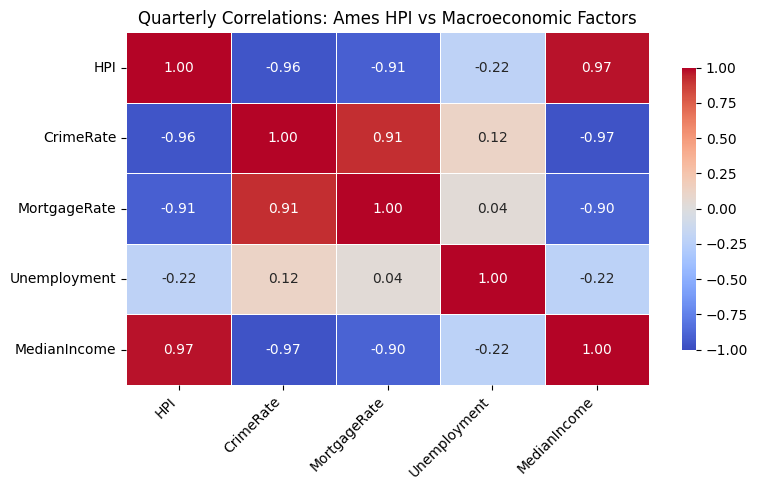

In [14]:
# Alternative: Explicitly select the numeric columns you want to include
numeric_columns = ['HPI', 'CrimeRate', 'MortgageRate', 'Unemployment', 'MedianIncome']
correlation_matrix = df_q_clean[numeric_columns].corr()

# Create the heatmap
plt.figure(figsize=(8, 5))
ax = sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
                 linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Quarterly Correlations: Ames HPI vs Macroeconomic Factors", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

# Save the figure
out_path = Path("output") / "macroeconomic_correlation_heatmap.png"
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()